![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# **03 | Hypotheses and Visualisation**

### *Project 1 — SQL: From Data to Insight*

## **Team:** **Bright Jaato**

## **Dataset:** **CO<sub>2</sub> Reduction Electrocatalyst Dataset — Malek et al. (2021)**

---

**This notebook is your report.** It is read on its own, by someone who has not seen notebooks 01 and 02, so it needs the prose as much as the code: the question, the evidence, and what you concluded. Keep the messy exploration in the other two.

> **Done when:** someone who has never met your project can read this top to bottom and understand what you asked, what the data said, and how confident they should be.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [1]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
# 1. Define the path to the SQLite database.
# 2. Open a connection to the database.

db_path = Path("../data/project.db")
conn = sqlite3.connect(db_path)

---
## **1. The question**

This project investigates how catalyst identity, product, electrolyte, temperature, and reported operating metrics are associated with performance in a literature-derived CO<sub>2</sub> electroreduction dataset.

The analysis focuses on four main research questions.

### Research Question 1
**How do Faradaic efficiency and current density vary across catalyst–product combinations in the low-temperature dataset?**

**Expectation:** Average Faradaic efficiency and current density will differ across catalyst–product combinations, indicating that performance depends on both catalyst identity and the reported product.

### Research Question 2
**Which catalyst–product combinations combine above-average Faradaic efficiency and current density with below-average reported cost in the low-temperature dataset?**

**Expectation:** Only a subset of catalyst–product combinations will satisfy all three criteria simultaneously, revealing trade-offs between electrochemical performance and reported cost.

### Research Question 3
**How does total current density vary across catalyst–electrolyte combinations in the second experimental dataset?**

**Expectation:** Total current density will vary across catalyst–electrolyte combinations, suggesting that the reported performance should be examined at the combined system level rather than by catalyst identity alone.

### Research Question 4
**How are catalyst, electrolyte, and total current density distributed across the distinct temperature groups in the second experimental dataset?**

**Expectation:** The low- and high-temperature groups will contain different catalyst–electrolyte systems and current-density distributions. These differences will be interpreted descriptively rather than as evidence of a causal temperature effect.

---
## **2. The data**

The dataset comes from Malek et al. (2021), *A Data-Driven Framework for the Accelerated Discovery of CO<sub>2</sub> Reduction Electrocatalysts*. The original Excel workbook contains multiple experimental data blocks with different reported variables.

For this project, two experimental datasets were extracted and analysed separately:

- **Low-temperature dataset:** 101 experimental records containing catalyst, product, reported cost, applied potential, Faradaic efficiency, current density, selectivity, and production rate.
- **Second experimental dataset:** 181 records containing catalyst, electrolyte, product, temperature, total current density, and either voltage or Faradaic efficiency.

### What does one row represent?

In the low-temperature dataset, one row represents one literature-derived catalyst–product experimental record with its associated reported performance metrics.

In the second experimental dataset, one row represents one literature-derived experimental record defined by catalyst, electrolyte, product, temperature, total current density, and the reported voltage or Faradaic efficiency.

### Database structure

The cleaned data were reorganized into a relational SQLite database containing five tables:

| Table | Purpose |
|---|---|
| `catalysts` | Stores unique catalyst names |
| `products` | Stores unique product names |
| `electrolytes` | Stores unique electrolyte names |
| `low_temp_experiments` | Stores measurements from the low-temperature dataset |
| `second_experiments` | Stores measurements from the second experimental dataset |

The lookup tables reduce repeated categorical information, while primary and foreign keys connect each experimental record to its corresponding catalyst, product, and electrolyte.

### Entity Relationship Diagram

The database relationships are shown below. Each lookup-table record can be associated with multiple experimental records, while each experiment references one corresponding catalyst, product, and, where applicable, electrolyte.

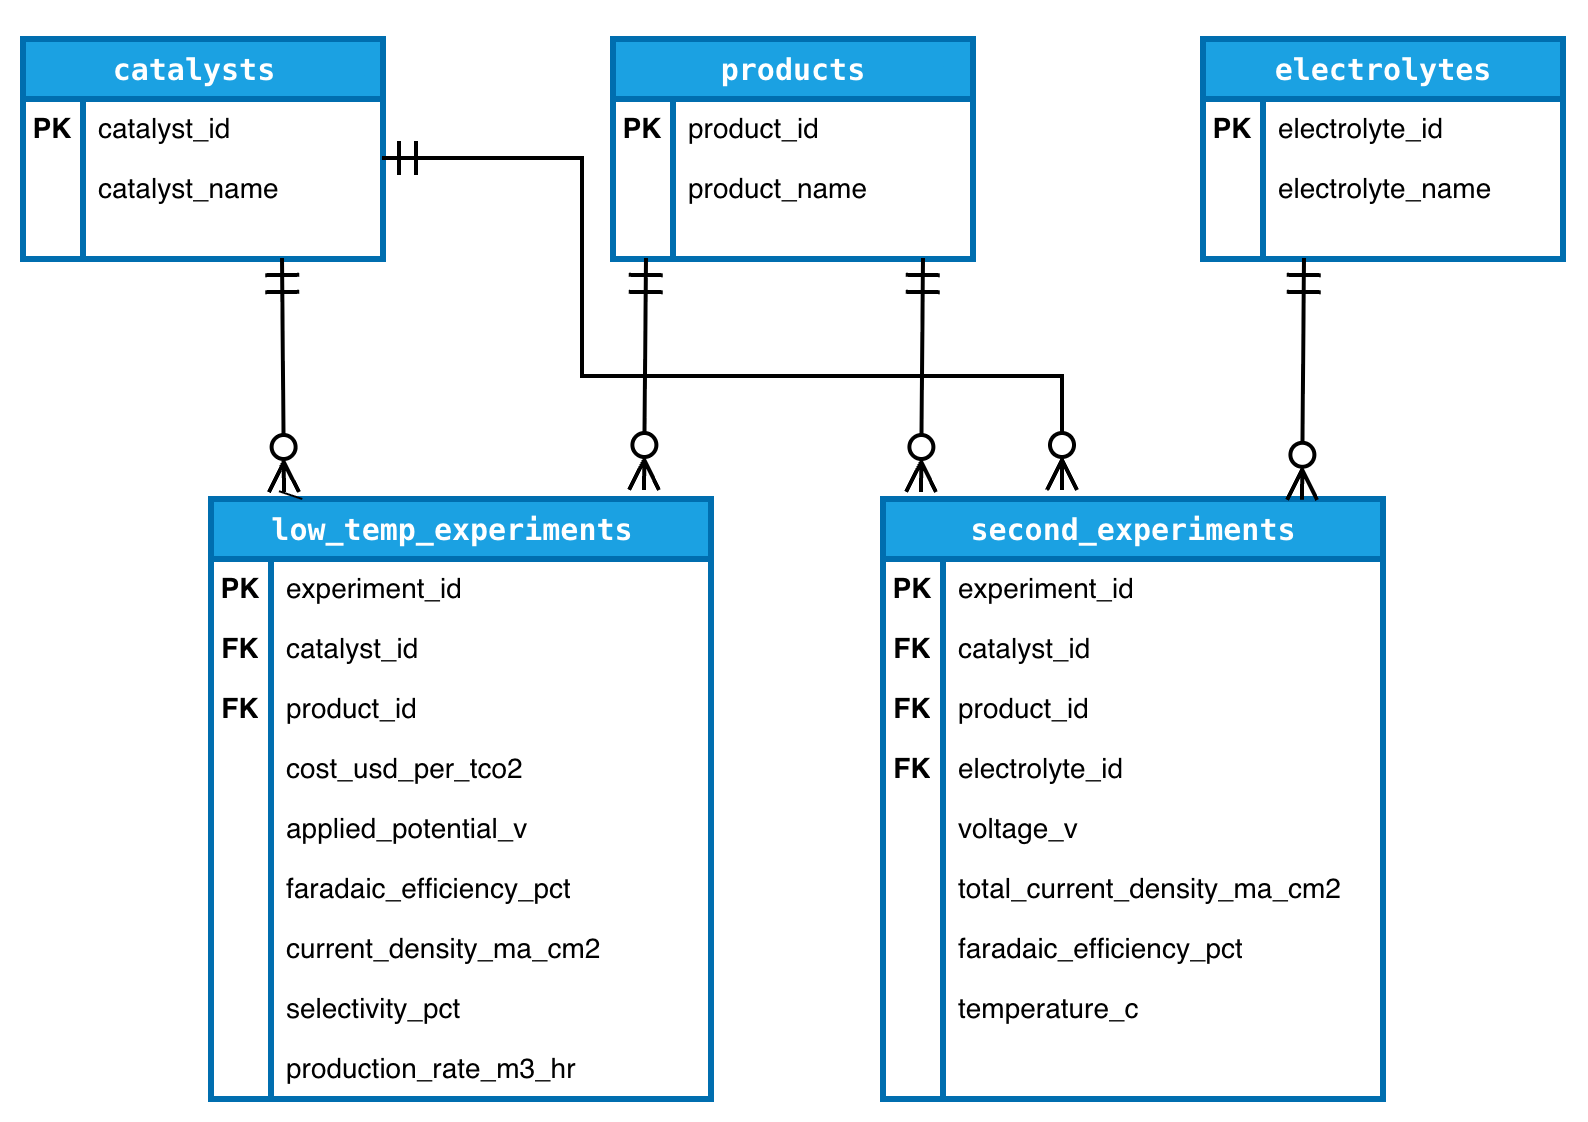

---
## **3. Analysis**

The research questions were evaluated using SQL queries against the relational database. Aggregation and filtering were performed in SQL, while pandas is used here only to display the query results for interpretation.

### **3.1 Catalyst–product performance**

**Research Question 1:**  

How do Faradaic efficiency and current density vary across catalyst–product combinations in the low-temperature dataset?

In [3]:
# 1. Join the low-temperature experiments with catalyst and product names.
# 2. Group records by catalyst-product combination.
# 3. Calculate the number of observations, average Faradaic efficiency,
#    and average current density.
# 4. Rank combinations by average Faradaic efficiency.

q1 = """
SELECT
    c.catalyst_name,
    p.product_name,
    COUNT(*) AS experiment_count,
    ROUND(AVG(l.faradaic_efficiency_pct), 2) AS avg_faradaic_efficiency_pct,
    ROUND(AVG(l.current_density_ma_cm2), 2) AS avg_current_density_ma_cm2
FROM low_temp_experiments AS l
JOIN catalysts AS c
    ON l.catalyst_id = c.catalyst_id
JOIN products AS p
    ON l.product_id = p.product_id
GROUP BY
    c.catalyst_name,
    p.product_name
ORDER BY
    avg_faradaic_efficiency_pct DESC;
"""

q1_result = pd.read_sql_query(q1, conn)
q1_result

,catalyst_name,product_name,experiment_count,avg_faradaic_efficiency_pct,avg_current_density_ma_cm2
0,Ir,C2H5OH,1,89.49,557.18
1,Ir,H2,1,86.75,164.19
2,Ir,HCOOH,2,84.22,713.44
3,Au,C2H5OH,1,84.08,873.40
4,Ag,CO,5,78.16,686.37
5,Pd,H2,2,78.15,255.77
6,C,CO,4,74.09,398.81
7,Sn,CO,2,71.29,372.35
8,C,CH4,1,71.28,93.43
9,Au,H2,3,64.37,539.55


### **Observation**

Catalyst–product combinations showed substantial variation in both Faradaic efficiency and current density. Average Faradaic efficiency ranged from **10.52% for Pd–CH₄** to **89.49% for Ir–C₂H₅OH**, while average current density ranged from **93.43 mA/cm² for C–CH₄** to **873.40 mA/cm² for Au–C₂H₅OH**.

Ir–HCOOH combined relatively high average Faradaic efficiency (**84.22%**) with high average current density (**713.44 mA/cm²**). However, several highly ranked combinations were represented by only one or two observations, so the rankings should be interpreted descriptively rather than as definitive performance comparisons.

### **3.2 Performance–cost trade-off**

**Research Question 2:** 
 
Which catalyst–product combinations combine above-average Faradaic efficiency and current density with below-average reported cost in the low-temperature dataset?

To identify combinations that balance performance and cost, catalyst–product groups are compared with the overall dataset averages for Faradaic efficiency, current density, and reported cost.

In [4]:
# 1. Join experiments with catalyst and product names.
# 2. Group by catalyst-product combination.
# 3. Calculate average Faradaic efficiency, current density, and cost.
# 4. Compare each group with the overall dataset averages.
# 5. Keep only combinations with:
#    - above-average Faradaic efficiency,
#    - above-average current density,
#    - below-average reported cost.

q2 = """
SELECT
    c.catalyst_name,
    p.product_name,
    COUNT(*) AS experiment_count,
    ROUND(AVG(l.faradaic_efficiency_pct), 2) AS avg_faradaic_efficiency_pct,
    ROUND(AVG(l.current_density_ma_cm2), 2) AS avg_current_density_ma_cm2,
    ROUND(AVG(l.cost_usd_per_tco2), 2) AS avg_cost_usd_per_tco2
FROM low_temp_experiments AS l
JOIN catalysts AS c
    ON l.catalyst_id = c.catalyst_id
JOIN products AS p
    ON l.product_id = p.product_id
GROUP BY
    c.catalyst_name,
    p.product_name
HAVING
    AVG(l.faradaic_efficiency_pct) >
        (SELECT AVG(faradaic_efficiency_pct)
         FROM low_temp_experiments)
    AND AVG(l.current_density_ma_cm2) >
        (SELECT AVG(current_density_ma_cm2)
         FROM low_temp_experiments)
    AND AVG(l.cost_usd_per_tco2) <
        (SELECT AVG(cost_usd_per_tco2)
         FROM low_temp_experiments)
ORDER BY
    avg_faradaic_efficiency_pct DESC,
    avg_current_density_ma_cm2 DESC;
"""

q2_result = pd.read_sql_query(q2, conn)
q2_result

,catalyst_name,product_name,experiment_count,avg_faradaic_efficiency_pct,avg_current_density_ma_cm2,avg_cost_usd_per_tco2
0,Ir,HCOOH,2,84.22,713.44,2745.48
1,Ag,CO,5,78.16,686.37,3501.96
2,Cu,CO,3,61.00,527.84,4611.31
3,Ag,H2,3,56.60,690.19,2961.94


### **Observation**

Only four catalyst–product combinations satisfied all three criteria simultaneously.

Ir–HCOOH showed the highest average Faradaic efficiency among the qualifying combinations (**84.22%**) together with a high average current density (**713.44 mA/cm²**) and an average reported cost of **2745.48 USD/tCO<sub>2</sub>**.

Ag–CO also showed strong performance (**78.16% FE; 686.37 mA/cm²**) and was supported by **five observations**, making it one of the more consistently represented combinations in the filtered set.

These results indicate that strong electrochemical performance and lower reported cost are achieved by only a subset of the catalyst–product combinations in the dataset.

### **3.3 Catalyst–electrolyte performance**

**Research Question 3:**  

How does total current density vary across catalyst–electrolyte combinations in the second experimental dataset?

To compare catalyst–electrolyte systems, the second experimental dataset is grouped by catalyst and electrolyte, and the average, minimum, and maximum total current density are calculated for each combination.

In [5]:
# 1. Join the second experimental dataset with catalyst and electrolyte names.
# 2. Group records by catalyst-electrolyte combination.
# 3. Count the number of observations in each group.
# 4. Calculate average, minimum, and maximum total current density.
# 5. Rank combinations by average total current density.

q3 = """
SELECT
    c.catalyst_name,
    e.electrolyte_name,
    COUNT(*) AS experiment_count,
    ROUND(AVG(s.total_current_density_ma_cm2), 2)
        AS avg_total_current_density_ma_cm2,
    ROUND(MIN(s.total_current_density_ma_cm2), 2)
        AS min_total_current_density_ma_cm2,
    ROUND(MAX(s.total_current_density_ma_cm2), 2)
        AS max_total_current_density_ma_cm2
FROM second_experiments AS s
JOIN catalysts AS c
    ON s.catalyst_id = c.catalyst_id
JOIN electrolytes AS e
    ON s.electrolyte_id = e.electrolyte_id
GROUP BY
    c.catalyst_name,
    e.electrolyte_name
ORDER BY
    avg_total_current_density_ma_cm2 DESC;
"""

q3_result = pd.read_sql_query(q3, conn)
q3_result

,catalyst_name,electrolyte_name,experiment_count,avg_total_current_density_ma_cm2,min_total_current_density_ma_cm2,max_total_current_density_ma_cm2
0,Ni-YSZ,YSZ,39,446.03,0.42,865.02
1,Ni-YSZ,CGO-YSZ,22,412.02,87.22,770.20
2,Ag/C,KOH-Nafion-K2SO4,12,215.45,105.38,349.05
3,Ti,Li2O-Li2CO3,41,188.94,24.83,552.10
4,Ag-C,KHCO3-Sustanion-PTFE,3,166.00,90.53,250.34
5,Au-MWCNT-PyPBI-Nafion-C,KOH,18,155.82,3.49,528.22
6,Ag-MWCNT-Nafion,KOH,12,136.25,3.49,343.14
7,Ag/C,KHCO3-Sustanion-PTFE,10,109.14,51.05,177.02
8,Ag,KK2SO4-KHCO3-ZrO2-K2SO4-KHCO3,24,109.00,23.09,300.48


### **Observation**

Total current density varied substantially across catalyst–electrolyte combinations.

Ni–YSZ with YSZ showed the highest average total current density (**446.03 mA/cm²; n = 39**), followed by Ni–YSZ with CGO–YSZ (**412.02 mA/cm²; n = 22**).

Considerable within-group variation was also observed. For example, Ni–YSZ with YSZ ranged from **0.42 to 865.02 mA/cm²**.

Ag/C also showed different average current densities with different electrolytes: **215.45 mA/cm²** with KOH–Nafion–K₂SO₄ compared with **109.14 mA/cm²** with KHCO₃–Sustanion–PTFE.

These results support analysing the catalyst and electrolyte as a combined system. The differences are descriptive and should not be interpreted as evidence of a causal electrolyte effect.

### **3.4 Temperature-group comparison**

**Research Question 4:**  

How are catalyst, electrolyte, and total current density distributed across the distinct temperature groups in the second experimental dataset?

To examine the two distinct temperature clusters identified during EDA, the second experimental dataset is divided into low- and high-temperature groups and compared by catalyst, electrolyte, and average total current density.

In [6]:
# 1. Join the second experimental dataset with catalyst and electrolyte names.
# 2. Use CASE to assign records to temperature groups.
# 3. Group by temperature group, catalyst, and electrolyte.
# 4. Count observations and calculate average total current density.
# 5. Sort temperature groups in logical order.

q4 = """
SELECT
    CASE
        WHEN s.temperature_c <= 100 THEN 'Low temperature'
        WHEN s.temperature_c >= 750 THEN 'High temperature'
        ELSE 'Intermediate temperature'
    END AS temperature_group,

    c.catalyst_name,
    e.electrolyte_name,
    COUNT(*) AS experiment_count,

    ROUND(
        AVG(s.total_current_density_ma_cm2),
        2
    ) AS avg_total_current_density_ma_cm2

FROM second_experiments AS s

JOIN catalysts AS c
    ON s.catalyst_id = c.catalyst_id

JOIN electrolytes AS e
    ON s.electrolyte_id = e.electrolyte_id

GROUP BY
    temperature_group,
    c.catalyst_name,
    e.electrolyte_name

ORDER BY
    CASE temperature_group
        WHEN 'Low temperature' THEN 1
        WHEN 'Intermediate temperature' THEN 2
        WHEN 'High temperature' THEN 3
    END,
    avg_total_current_density_ma_cm2 DESC;
"""

q4_result = pd.read_sql_query(q4, conn)
q4_result

,temperature_group,catalyst_name,electrolyte_name,experiment_count,avg_total_current_density_ma_cm2
0,Low temperature,Ag/C,KOH-Nafion-K2SO4,12,215.45
1,Low temperature,Ag-C,KHCO3-Sustanion-PTFE,3,166.00
2,Low temperature,Au-MWCNT-PyPBI-Nafion-C,KOH,18,155.82
3,Low temperature,Ag-MWCNT-Nafion,KOH,12,136.25
4,Low temperature,Ag/C,KHCO3-Sustanion-PTFE,10,109.14
5,Low temperature,Ag,KK2SO4-KHCO3-ZrO2-K2SO4-KHCO3,24,109.00
6,High temperature,Ni-YSZ,YSZ,39,446.03
7,High temperature,Ni-YSZ,CGO-YSZ,22,412.02
8,High temperature,Ti,Li2O-Li2CO3,41,188.94


### **Observation**

The low- and high-temperature groups contained clearly different catalyst–electrolyte systems and different current-density patterns.

The highest average total current densities were observed in the high-temperature group for Ni–YSZ/YSZ (**446.03 mA/cm²; n = 39**) and Ni–YSZ/CGO–YSZ (**412.02 mA/cm²; n = 22**).

In the low-temperature group, the highest average total current density was observed for Ag/C with KOH–Nafion–K₂SO₄ at **215.45 mA/cm² (n = 12)**.

No intermediate-temperature records were observed. Because the catalyst–electrolyte composition differs substantially between the temperature groups, these differences should be interpreted descriptively and not as evidence that temperature alone caused the change in current density.

**Note:** The temperature thresholds reflect the two distinct clusters observed during EDA, approximately **25–100 °C** and **750–900 °C**.

---
## **4. Visualisation**

The following visualisations highlight the main patterns identified through the SQL analysis.

### **4.1 Faradaic efficiency vs current density**

The first visualisation compares average Faradaic efficiency and average current density across catalyst–product combinations in the low-temperature dataset. Point size represents the number of observations supporting each combination.

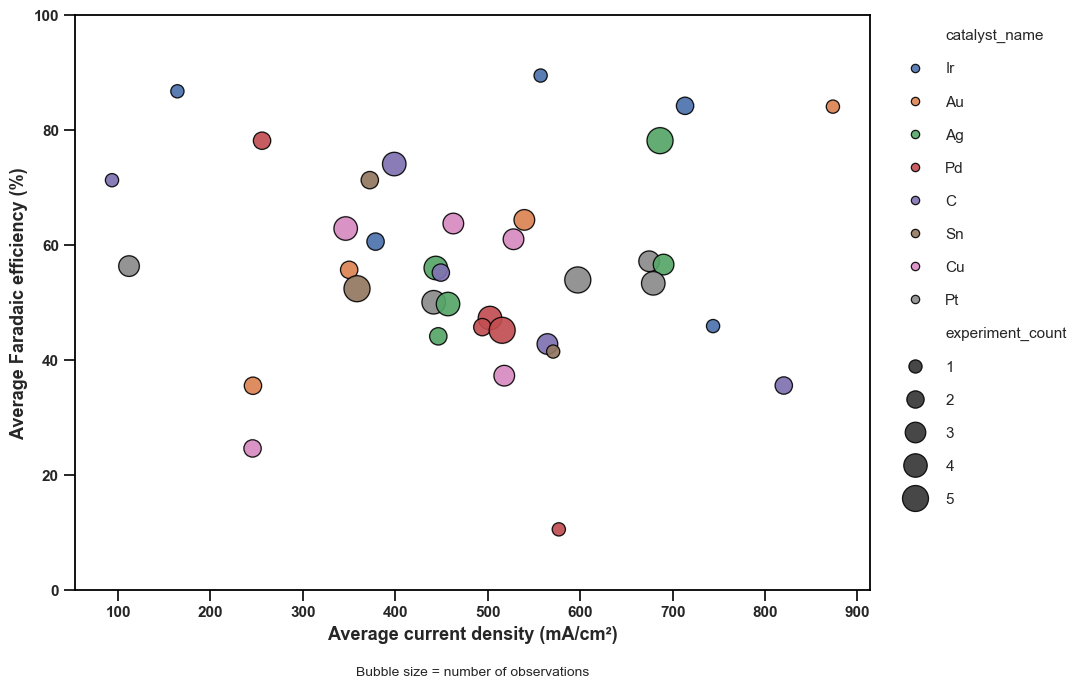

Saved presentation image to: ../images/rq1_catalyst_product_performance_clean_presentation.png


In [7]:
# Key Finding 1:
# Performance is multi-dimensional

plt.figure(figsize=(11, 7))

ax = plt.gca()

# --------------------------------------------------
# Remove grid
# --------------------------------------------------
ax.grid(False)

# --------------------------------------------------
# Add subtle shadow behind bubbles
# Gives the points a little visual depth
# --------------------------------------------------
sns.scatterplot(
    data=q1_result,
    x="avg_current_density_ma_cm2",
    y="avg_faradaic_efficiency_pct",
    size="experiment_count",
    sizes=(120, 420),
    color="black",
    alpha=0.12,
    legend=False,
    ax=ax
)

# --------------------------------------------------
# Main coloured bubbles
# Colour = catalyst
# Size = number of observations
# --------------------------------------------------
sns.scatterplot(
    data=q1_result,
    x="avg_current_density_ma_cm2",
    y="avg_faradaic_efficiency_pct",
    hue="catalyst_name",
    size="experiment_count",
    sizes=(90, 350),
    alpha=0.90,
    edgecolor="black",
    linewidth=0.9,
    ax=ax
)

# --------------------------------------------------
# Axis labels
# --------------------------------------------------
ax.set_xlabel(
    "Average current density (mA/cm²)",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Average Faradaic efficiency (%)",
    fontsize=13,
    fontweight="bold"
)

# --------------------------------------------------
# Axis limits
# FE naturally ranges from 0 to 100%
# --------------------------------------------------
ax.set_ylim(0, 100)

# Add a little breathing room on the x-axis
ax.set_xlim(
    q1_result["avg_current_density_ma_cm2"].min() - 40,
    q1_result["avg_current_density_ma_cm2"].max() + 40
)

# --------------------------------------------------
# Outward-facing ticks
# --------------------------------------------------
ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=8,
    width=1.4,
    labelsize=11,
    bottom=True,
    left=True,
    top=False,
    right=False
)

# --------------------------------------------------
# Bold x-axis tick values
# --------------------------------------------------
for label in ax.get_xticklabels():
    label.set_fontweight("bold")

# --------------------------------------------------
# Bold y-axis tick values
# --------------------------------------------------
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# --------------------------------------------------
# No internal plot title
# The PowerPoint slide already has the title
# --------------------------------------------------
ax.set_title("")

# --------------------------------------------------
# Full rectangular box around the plot
# --------------------------------------------------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.3)
    spine.set_color("black")

# --------------------------------------------------
# Legend
# Extra vertical spacing prevents size circles
# from appearing merged
# --------------------------------------------------
legend = ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    labelspacing=1.25,
    handletextpad=1.0,
    borderaxespad=0.5
)

# --------------------------------------------------
# Explain bubble size
# --------------------------------------------------
ax.text(
    0.5,
    -0.15,
    "Bubble size = number of observations",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

# --------------------------------------------------
# Final layout
# --------------------------------------------------
plt.tight_layout()

# --------------------------------------------------
# Save high-resolution image for PowerPoint
# --------------------------------------------------
output_path = "../images/rq1_catalyst_product_performance_clean_presentation.png"

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Saved presentation image to: {output_path}")

### **Observation**

Catalyst–product combinations occupy a broad range of Faradaic efficiencies and current densities, showing that high performance in one metric does not automatically correspond to high performance in the other.

Several combinations appear in the upper-right region of the plot, indicating relatively high values for both metrics. However, point size shows that some highly ranked combinations are supported by relatively few observations. Therefore, performance should be interpreted together with the number of records contributing to each average.

### **4.2 Performance–cost trade-off**

Research Question 2 identified catalyst–product combinations with above-average Faradaic efficiency and current density but below-average reported cost.

The plot shows all catalyst–product combinations, while the four systems that meet all three screening criteria are highlighted. Point size represents the number of observations supporting each combination.

Reported cost is included in the screening criteria rather than encoded directly in the bubble size.

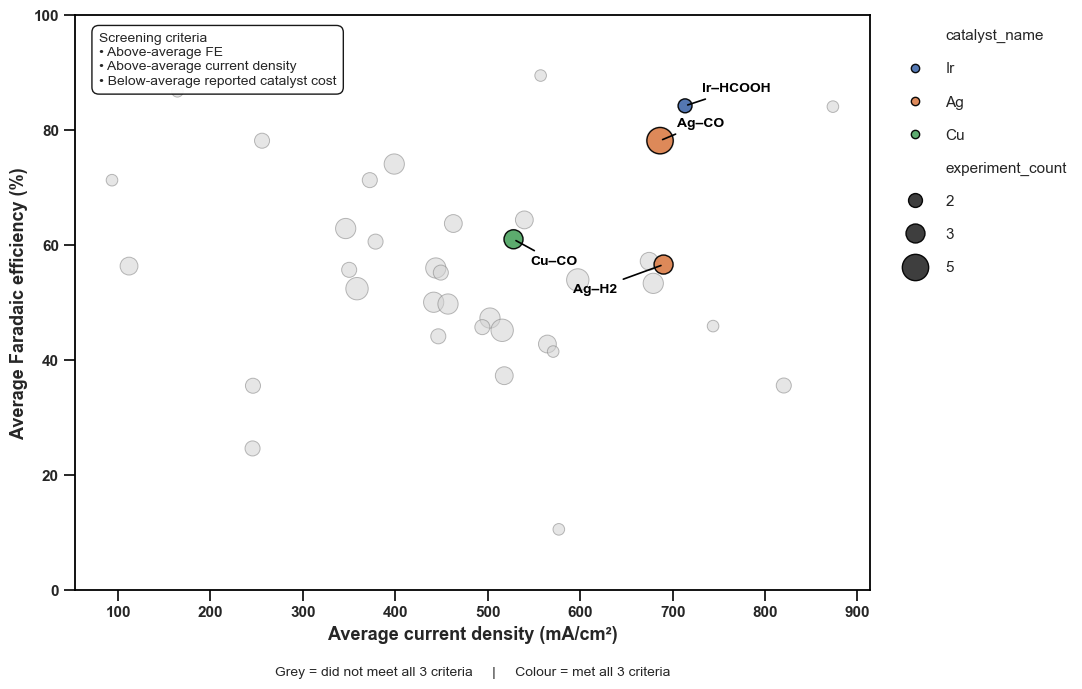

Saved presentation image to: ../images/rq2_multicriteria_screening_presentation.png


In [8]:
# Key Finding 2:
# Multi-criteria screening narrows the field

plt.figure(figsize=(11, 7))

ax = plt.gca()
ax.grid(False)

# --------------------------------------------------
# Create labels for each catalyst-product combination
# --------------------------------------------------
q1_plot = q1_result.copy()

q1_plot["combination"] = (
    q1_plot["catalyst_name"].astype(str)
    + "–"
    + q1_plot["product_name"].astype(str)
)

q2_plot = q2_result.copy()

q2_plot["combination"] = (
    q2_plot["catalyst_name"].astype(str)
    + "–"
    + q2_plot["product_name"].astype(str)
)

# --------------------------------------------------
# Identify the combinations that passed screening
# --------------------------------------------------
selected_combinations = q2_plot["combination"].tolist()

selected_df = q1_plot[
    q1_plot["combination"].isin(selected_combinations)
].copy()

background_df = q1_plot[
    ~q1_plot["combination"].isin(selected_combinations)
].copy()

# --------------------------------------------------
# Plot non-selected systems in light grey
# --------------------------------------------------
sns.scatterplot(
    data=background_df,
    x="avg_current_density_ma_cm2",
    y="avg_faradaic_efficiency_pct",
    size="experiment_count",
    sizes=(70, 260),
    color="lightgray",
    alpha=0.55,
    edgecolor="gray",
    linewidth=0.7,
    legend=False,
    ax=ax
)

# --------------------------------------------------
# Add subtle shadow behind selected bubbles
# --------------------------------------------------
sns.scatterplot(
    data=selected_df,
    x="avg_current_density_ma_cm2",
    y="avg_faradaic_efficiency_pct",
    size="experiment_count",
    sizes=(130, 430),
    color="black",
    alpha=0.12,
    legend=False,
    ax=ax
)

# --------------------------------------------------
# Highlight selected systems in colour
# --------------------------------------------------
sns.scatterplot(
    data=selected_df,
    x="avg_current_density_ma_cm2",
    y="avg_faradaic_efficiency_pct",
    hue="catalyst_name",
    size="experiment_count",
    sizes=(100, 360),
    alpha=0.95,
    edgecolor="black",
    linewidth=1.0,
    ax=ax
)

# --------------------------------------------------
# Helper function for selected-point labels
# --------------------------------------------------
def label_selected(catalyst, product, xytext=(10, 10)):

    row = selected_df[
        (selected_df["catalyst_name"] == catalyst)
        & (selected_df["product_name"] == product)
    ]

    if not row.empty:
        x = row.iloc[0]["avg_current_density_ma_cm2"]
        y = row.iloc[0]["avg_faradaic_efficiency_pct"]

        ax.annotate(
            f"{catalyst}–{product}",
            xy=(x, y),
            xytext=xytext,
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
            color="black",
            arrowprops=dict(
                arrowstyle="-",
                color="black",
                linewidth=1.2
            )
        )

# --------------------------------------------------
# Label the four selected combinations
# --------------------------------------------------
label_selected("Ir", "HCOOH", (12, 10))
label_selected("Ag", "CO", (12, 10))
label_selected("Cu", "CO", (12, -18))
label_selected("Ag", "H2", (-65, -20))

# --------------------------------------------------
# Axis labels
# --------------------------------------------------
ax.set_xlabel(
    "Average current density (mA/cm²)",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Average Faradaic efficiency (%)",
    fontsize=13,
    fontweight="bold"
)

# --------------------------------------------------
# Axis limits
# --------------------------------------------------
ax.set_ylim(0, 100)

ax.set_xlim(
    q1_plot["avg_current_density_ma_cm2"].min() - 40,
    q1_plot["avg_current_density_ma_cm2"].max() + 40
)

# --------------------------------------------------
# Outward ticks
# --------------------------------------------------
ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=8,
    width=1.4,
    labelsize=11,
    bottom=True,
    left=True,
    top=False,
    right=False
)

# Make x-axis tick values bold
for label in ax.get_xticklabels():
    label.set_fontweight("bold")

# Make y-axis tick values bold
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# --------------------------------------------------
# Remove internal title
# --------------------------------------------------
ax.set_title("")

# --------------------------------------------------
# Keep full rectangular box around the plot
# --------------------------------------------------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.3)
    spine.set_color("black")

# --------------------------------------------------
# Legend
# --------------------------------------------------
legend = ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    labelspacing=1.25,
    handletextpad=1.0,
    borderaxespad=0.5
)

# --------------------------------------------------
# Screening criteria box
# --------------------------------------------------
screening_text = (
    "Screening criteria\n"
    "• Above-average FE\n"
    "• Above-average current density\n"
    "• Below-average reported catalyst cost"
)

ax.text(
    0.03,
    0.97,
    screening_text,
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="black",
        alpha=0.9
    )
)

# --------------------------------------------------
# Explain grey vs coloured points
# --------------------------------------------------
ax.text(
    0.5,
    -0.15,
    "Grey = did not meet all 3 criteria     |     Colour = met all 3 criteria",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

# --------------------------------------------------
# Final layout
# --------------------------------------------------
plt.tight_layout()

# --------------------------------------------------
# Save high-resolution image for PowerPoint
# --------------------------------------------------
output_path = "../images/rq2_multicriteria_screening_presentation.png"

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Saved presentation image to: {output_path}")

### **Observation**

The four qualifying catalyst–product combinations occupy a relatively high-performance region because they already satisfy the above-average Faradaic efficiency and current-density criteria.

Ir–HCOOH combines the highest average Faradaic efficiency among the qualifying combinations (**84.22%**) with a high average current density (**713.44 mA/cm²**) and the lowest average reported cost among the four (**2745.48 USD/tCO<sub>2</sub>**).

Ag–CO also occupies a strong performance region (**78.16% FE; 686.37 mA/cm²**) and is supported by five observations. The visualisation highlights that evaluating catalyst systems using multiple metrics provides more information than ranking them by Faradaic efficiency alone.

### **4.3 Catalyst–electrolyte current density**

This visualisation compares the average total current density reported for each catalyst–electrolyte combination in the second experimental dataset.

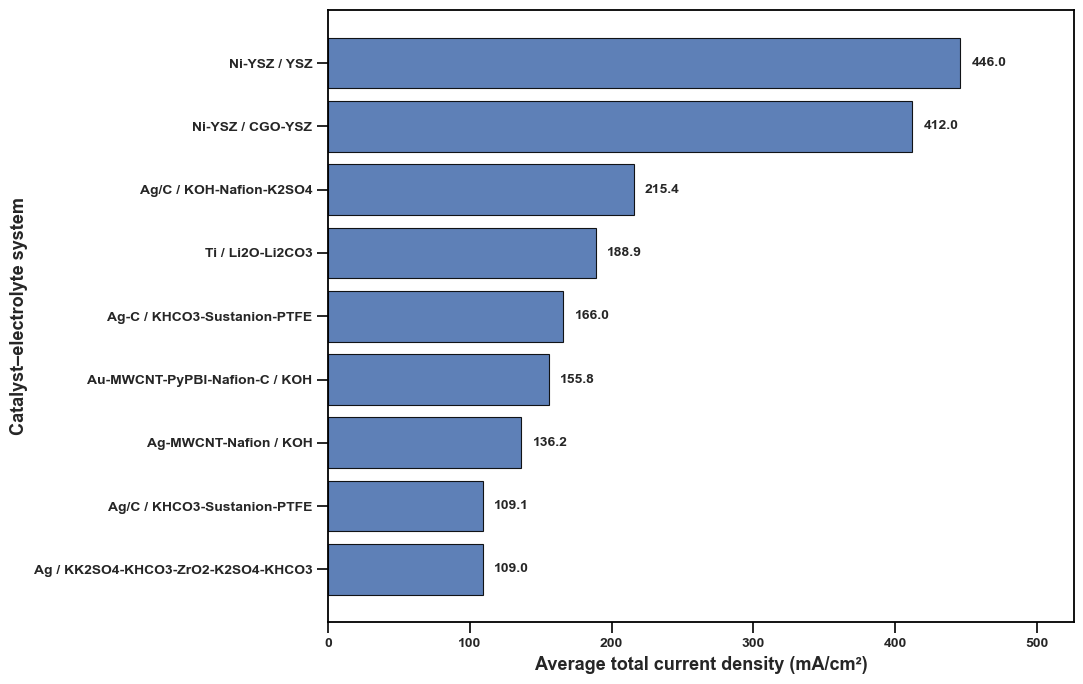

Saved presentation image to: ../images/rq3_catalyst_electrolyte_performance_presentation.png


In [9]:
# Key Finding 3A:
# Catalyst-electrolyte performance

# --------------------------------------------------
# Make a copy of the Q3 SQL result
# --------------------------------------------------
q3_plot = q3_result.copy()

# --------------------------------------------------
# Create a readable catalyst-electrolyte label
# --------------------------------------------------
q3_plot["system"] = (
    q3_plot["catalyst_name"].astype(str)
    + " / "
    + q3_plot["electrolyte_name"].astype(str)
)

# --------------------------------------------------
# Sort from highest to lowest average current density
# --------------------------------------------------
q3_plot = q3_plot.sort_values(
    "avg_total_current_density_ma_cm2",
    ascending=True
)

# --------------------------------------------------
# Create figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 7))

ax.grid(False)

# --------------------------------------------------
# Horizontal bar chart
# --------------------------------------------------
bars = ax.barh(
    q3_plot["system"],
    q3_plot["avg_total_current_density_ma_cm2"],
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9
)

# --------------------------------------------------
# Add values at the end of each bar
# --------------------------------------------------
for bar, value in zip(
    bars,
    q3_plot["avg_total_current_density_ma_cm2"]
):
    ax.text(
        value + 8,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# --------------------------------------------------
# Axis labels
# --------------------------------------------------
ax.set_xlabel(
    "Average total current density (mA/cm²)",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Catalyst–electrolyte system",
    fontsize=13,
    fontweight="bold"
)

# --------------------------------------------------
# Outward-facing ticks
# --------------------------------------------------
ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=8,
    width=1.4,
    labelsize=10,
    bottom=True,
    left=True,
    top=False,
    right=False
)

# --------------------------------------------------
# Bold tick values
# --------------------------------------------------
for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# --------------------------------------------------
# Full boxed frame
# --------------------------------------------------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.3)
    spine.set_color("black")

# --------------------------------------------------
# Give space for value labels
# --------------------------------------------------
ax.set_xlim(
    0,
    q3_plot["avg_total_current_density_ma_cm2"].max() * 1.18
)

# --------------------------------------------------
# No internal chart title
# --------------------------------------------------
ax.set_title("")

# --------------------------------------------------
# Layout
# --------------------------------------------------
plt.tight_layout()

# --------------------------------------------------
# Save for PowerPoint
# --------------------------------------------------
output_path = "../images/rq3_catalyst_electrolyte_performance_presentation.png"

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Saved presentation image to: {output_path}")

### **Observation**

Average total current density varied substantially across catalyst–electrolyte combinations.

Ni–YSZ with YSZ showed the highest average total current density (**446.03 mA/cm²**), followed by Ni–YSZ with CGO–YSZ (**412.02 mA/cm²**).

The plot also shows that combinations using the same catalyst can exhibit different average current densities with different electrolytes. For example, Ag/C averaged **215.45 mA/cm²** with KOH–Nafion–K₂SO₄ but **109.14 mA/cm²** with KHCO₃–Sustanion–PTFE.

These differences should be interpreted descriptively because the literature-derived records may also differ in other operating conditions.

### **4.4 Temperature-group comparison**

This visualisation compares the average total current density of catalyst–electrolyte combinations across the distinct temperature groups identified during EDA.

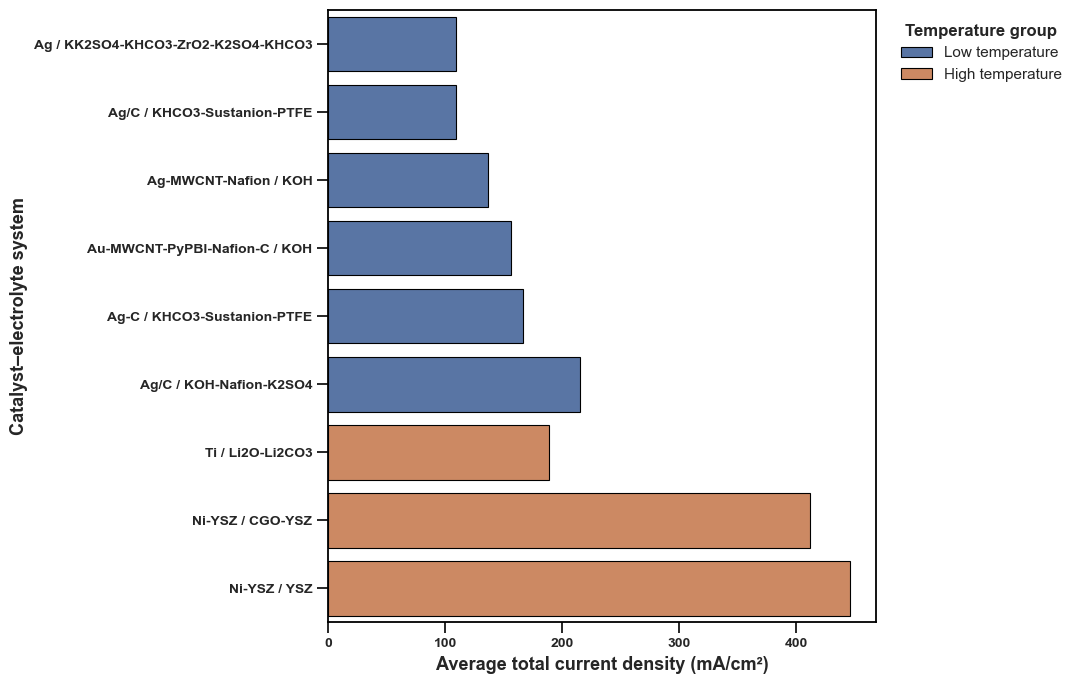

Saved presentation image to: ../images/rq4_temperature_group_comparison_grouped.png


In [10]:
# Key Finding 3B:
# Temperature-group comparison with systems grouped by temperature

q4_plot = q4_result.copy()

# Create readable catalyst-electrolyte labels
q4_plot["system"] = (
    q4_plot["catalyst_name"].astype(str)
    + " / "
    + q4_plot["electrolyte_name"].astype(str)
)

# --------------------------------------------------
# Order temperature groups explicitly
# --------------------------------------------------
temperature_order = ["Low temperature", "High temperature"]

q4_plot["temperature_group"] = pd.Categorical(
    q4_plot["temperature_group"],
    categories=temperature_order,
    ordered=True
)

# --------------------------------------------------
# Sort first by temperature group,
# then by average current density within each group
# --------------------------------------------------
q4_plot = q4_plot.sort_values(
    ["temperature_group", "avg_total_current_density_ma_cm2"],
    ascending=[True, True]
)

# --------------------------------------------------
# Create figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 7))

ax.grid(False)

# --------------------------------------------------
# Horizontal bar chart
# --------------------------------------------------
sns.barplot(
    data=q4_plot,
    y="system",
    x="avg_total_current_density_ma_cm2",
    hue="temperature_group",
    hue_order=temperature_order,
    orient="h",
    edgecolor="black",
    linewidth=0.8,
    ax=ax
)

# --------------------------------------------------
# Axis labels
# --------------------------------------------------
ax.set_xlabel(
    "Average total current density (mA/cm²)",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Catalyst–electrolyte system",
    fontsize=13,
    fontweight="bold"
)

# --------------------------------------------------
# Outward-facing ticks
# --------------------------------------------------
ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=8,
    width=1.4,
    labelsize=10,
    bottom=True,
    left=True,
    top=False,
    right=False
)

# Bold tick values
for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# --------------------------------------------------
# Full boxed frame
# --------------------------------------------------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.3)
    spine.set_color("black")

# --------------------------------------------------
# Clean legend
# --------------------------------------------------
legend = ax.legend(
    title="Temperature group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

legend.get_title().set_fontweight("bold")

# --------------------------------------------------
# No internal chart title
# --------------------------------------------------
ax.set_title("")

# --------------------------------------------------
# Layout
# --------------------------------------------------
plt.tight_layout()

# --------------------------------------------------
# Save high-resolution image for PowerPoint
# --------------------------------------------------
output_path = "../images/rq4_temperature_group_comparison_grouped.png"

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Saved presentation image to: {output_path}")

### **Observation**

The high-temperature group contains the two highest average total current densities in the dataset: Ni–YSZ/YSZ at **446.03 mA/cm²** and Ni–YSZ/CGO–YSZ at **412.02 mA/cm²**.

In the low-temperature group, the highest average total current density is observed for Ag/C with KOH–Nafion–K₂SO₄ at **215.45 mA/cm²**.

However, the catalyst–electrolyte systems represented in the low- and high-temperature groups are different. Therefore, the higher current densities observed in the high-temperature group should not be interpreted as evidence that temperature alone caused the difference.

### **Overall takeaway**

The analysis does not identify one universally best CO<sub>2</sub>RR system.

Instead, it shows that useful candidates emerge only when multiple
performance metrics, reported cost, electrolyte context, and operating
conditions are considered together.

The database can therefore support early-stage screening and prioritisation,
but the literature-derived nature of the data limits causal interpretation.

---
## **5. Conclusions**

The SQL analysis and visualisations support the main expectations of the project, while also showing important limitations related to unequal group sizes and differing operating conditions.

### Research Question 1

**How do Faradaic efficiency and current density vary across catalyst–product combinations?**

**Conclusion:**  

Catalyst–product combinations showed substantial variation in both Faradaic efficiency and current density. Some combinations performed strongly in one metric but not necessarily in the other, confirming that performance cannot be described using a single measure alone.

The expectation that performance would differ across catalyst–product combinations was **supported**.

### Research Question 2

**Which catalyst–product combinations combine above-average Faradaic efficiency and current density with below-average reported cost?**

**Conclusion:**  

Only four catalyst–product combinations satisfied all three criteria simultaneously. Ir–HCOOH showed the highest average Faradaic efficiency among the qualifying combinations, while Ag–CO also combined strong performance with a comparatively larger number of observations.

The expectation that only a subset of combinations would satisfy all three criteria was **supported**.

### Research Question 3

**How does total current density vary across catalyst–electrolyte combinations?**

**Conclusion:**  

Average total current density varied strongly across catalyst–electrolyte systems. Ni–YSZ/YSZ and Ni–YSZ/CGO–YSZ showed the highest average values. The same catalyst could also show different average current densities with different electrolytes.

The expectation that performance would vary across catalyst–electrolyte combinations was **supported**.

### Research Question 4

**How are catalyst, electrolyte, and total current density distributed across the distinct temperature groups?**

**Conclusion:**  

The low- and high-temperature groups contained different catalyst–electrolyte systems and different current-density distributions. The highest average current densities occurred in the high-temperature group, but the systems represented in the two groups were also different.

The expectation that the temperature groups would differ in both system composition and reported current density was **supported**. However, these differences should not be interpreted as evidence that temperature alone caused the observed performance differences.

---
## **6. Limitations and next steps**

### Limitations

This analysis provides useful descriptive insights, but several limitations should be considered.

- The dataset is literature-derived, so records were collected under different experimental conditions rather than under one standardized protocol.
- Some catalyst–product combinations are represented by only one or two observations, while others contain many more records. Group averages therefore differ in statistical support.
- Catalyst, electrolyte, temperature, and other operating conditions vary together in parts of the dataset. This makes it inappropriate to interpret observed differences as evidence of causation.
- In the second experimental dataset, voltage and Faradaic efficiency are reported in complementary subsets of records rather than simultaneously. This limits direct comparison between these two variables.
- Reported cost and production-rate values originate from the source dataset and should be interpreted within the assumptions and methodology used to generate them.
- The analysis relies mainly on grouped averages, which can hide substantial variation within catalyst–product or catalyst–electrolyte combinations.

### Next steps

With additional time, the analysis could be extended by:

1. investigating the influence of additional operating variables such as applied potential and temperature while controlling for catalyst and electrolyte identity;
2. examining distributions and variability within groups rather than relying only on averages;
3. defining minimum sample-size criteria for more robust catalyst-system comparisons;
4. developing a multi-objective ranking framework that considers Faradaic efficiency, current density, cost, selectivity, and production rate simultaneously;
5. applying statistical or machine-learning methods to investigate which experimental variables are most strongly associated with performance;
6. expanding the dataset with additional standardized CO<sub>2</sub> electroreduction studies to improve coverage and comparability.

Overall, the project demonstrates how relational database design, SQL analysis, and visualisation can be combined to extract structured insights from heterogeneous electrochemical literature data while maintaining appropriate caution in interpretation.